# **Linear Regression From Scratch**

In [319]:
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

In [320]:
df = load_diabetes(as_frame=True)

df = df.frame  # her using as_frame = True makes every feature as dataframe and for one column it makes it series and when .frame done it adds all series and dataframe in one
df.head(10)

X = df.drop('target' , axis = 1)
y = df['target']

X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    shuffle=True,
    stratify=None,
    test_size=0.2,
    random_state=42
)

X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

## **2. Initialize Parameters**

In [321]:
w = np.zeros(X_train.shape[1])
b = 0.0

learning_rate = 0.1
itr = 10000
m = X_train.shape[0]


## **3. Forward Propagation (Prediction)**

In [322]:
def predict(w , X_train , b):
    return X_train @ w + b

## **4. Calculate Loss (Cost Function)**

In [323]:
def cost_func(y_hat , y_train , m):
    return np.sum((y_hat - y_train) ** 2) / (2 * m)

## **5. Compute Gradients**

In [324]:
def gradient_w(y_hat , y_train , m , X_train):
    return (X_train.T @ (y_hat - y_train)) / m

def gradient_b(y_hat , y_train , m):
    return np.sum(y_hat - y_train) / m

## **Now Looping to find w and b**

In [325]:
cost_history = []

for i in range(itr):

    y_hat = predict(w, X_train, b)

    cost = cost_func(y_hat, y_train , m)

    if i <= 1000:    # Storing starting 100 iterations cost
        cost_history.append(cost)

    dw = gradient_w(y_hat , y_train , m , X_train)
    db = gradient_b(y_hat , y_train , m)

    w = w - learning_rate * dw
    b = b - learning_rate * db




## **Prediction**

In [326]:
y_predicted = predict(w , X_test , b)

print("MAE :", mean_absolute_error(y_test, y_predicted))
print("MSE :", mean_squared_error(y_test, y_predicted))
print("RMSE:", root_mean_squared_error(y_test, y_predicted))
print("R² :", r2_score(y_test, y_predicted))

MAE : 43.014022098012276
MSE : 2866.8787202494273
RMSE: 53.543241592655065
R² : 0.45889078751809864


## **Linear Regression Model Score on same Data**

In [327]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

predicted = lr.predict(X_test)

print("MAE :", mean_absolute_error(y_test, predicted))
print("MSE :", mean_squared_error(y_test, predicted))
print("RMSE:", root_mean_squared_error(y_test, predicted))
print("R² :", r2_score(y_test, predicted))


MAE : 42.79409467959994
MSE : 2900.1936284934804
RMSE: 53.85344583676592
R² : 0.4526027629719196


## **Visual Representation of how cost drop smoothly with increase in iteration**

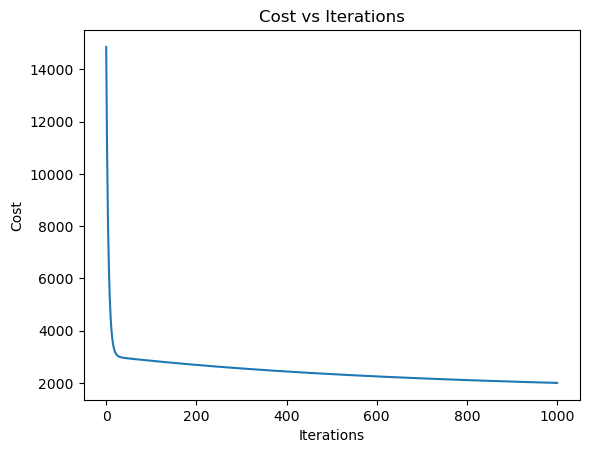

In [328]:
import matplotlib.pyplot as plt

plt.plot(range(0 , len(cost_history)) , cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.show()

> **Conclusion:**
> In this notebook, I implemented **Multiple Linear Regression from scratch** using fully vectorized NumPy operations and Gradient Descent, without relying on scikit-learn's training functions. The model was trained by iteratively updating the weights and bias using the gradients of the Mean Squared Error (MSE) cost function. After tuning the learning rate (`0.1`) and increasing the number of iterations (`10000`), the model converged successfully and achieved an **R² score of approximately 0.46**, which is comparable to scikit-learn's `LinearRegression` implementation. This project demonstrates a complete understanding of the mathematical foundations of linear regression, vectorized implementation, optimization using gradient descent, and model evaluation using MAE, MSE, RMSE, and R² score.
